# Lab3: Motor Insurance Case Study

The purpose of this notebook is to apply the CRISPDM steps of data understanding and data preparation, using 
the data from the Motor Insurance Case Study. We do this by preparing the **Data Quality Report** and the **Data Quality Plan** for the given dataset. For a description of the business problem and analytics solution, as well as details about the problem domain and features, please consult the FMLPDA textbook.

1. ## Data Understanding: Data Quality Report (Lab 3)
The data quality report uses tables and visualisations to explore the data.
For each feature in the dataframe, we prepare summary tables (with descriptive stats) and plots.

    Stats Tables: One table for continuous features and one table for categorical features. We need to have an understanding of what the features mean, to be able to decide an initial grouping of features into continuous and categorical. Please consult the FMLPDA textbook to get an understanding of the feature meaning.

    Plots: For continuous features, we prepare histograms and box plots. For categorical features, we prepare bar plots. Lab3 and Lab 4 show example steps and code for how to do this.

    The Data Quality Report helps us identify potential problems or errors in the data. It serves as a summary of our findings from the dataset.

2. ## Data Understanding: Data Quality Plan (Lab 4)
The data quality plan lists each feature and a set of strategies to handle potential problems in the data.
We aim to find potential data quality problems and to prepare a table (a plan) which lists the problem found for each feature and solutions for fixing the problem. We also list the actions we are going to take for each feature, e.g., leave as is, remove extreme outliers, replace missing data, drop feature if too many missing values, etc. If there is no issue with the feature, we also state this, eg no issues, keep as is.

## Data Quality Report: Tables


## Step 1: Load Required Libraries

Before we can analyze data, we need to import the necessary Python packages. Below, we import:
- **pandas**: for working with dataframes and CSV files
- **numpy**: for numerical computations
- **matplotlib**: for creating visualizations

In [59]:
# From your virtul environment, install the pandas package for working with data frames: 
# pip install pandas
# pandas is an open source Python library for data analysis
# A data frame allows us to read and access data stored in spreadsheet (.csv) format
# Good tutorial on pandas: http://pandas.pydata.org/pandas-docs/stable/10min.html
# Pandas Cookbook: http://pandas.pydata.org/pandas-docs/stable/tutorials.html
# Another good resource for pandas: http://chrisalbon.com/python/pandas_dataframe_importing_csv.htm

#Import the required packages
#Import package pandas for data analysis
import pandas as pd

# Import package numpy for numeric computing
import numpy as np

# Import package matplotlib for visualisation/plotting
import matplotlib.pyplot as plt

#For showing plots directly in the notebook run the command below
%matplotlib inline

### Helper Functions for Data Quality Analysis

Let's define reusable functions to avoid code repetition and improve maintainability.

In [60]:
def build_dqr_table(df, columns, csv_filename):
    """
    Build and save a Data Quality Report table.
    
    Parameters:
    -----------
    df : pandas.DataFrame
    columns : Index
        Features to include
    csv_filename : str
        Output filename
    
    Returns:
    --------
    pandas.DataFrame
        Complete DQR table
    """
    stats = df[columns].describe().T
    perc_missing = 100 * (df[columns].isnull().sum() / len(df))
    cardinality = df[columns].nunique()
    
    dqr_table = pd.concat([
        stats,
        pd.DataFrame(perc_missing, columns=['%missing']),
        pd.DataFrame(cardinality, columns=['cardinality'])
    ], axis=1)
    
    dqr_table.to_csv(csv_filename, index_label='Feature')
    return dqr_table


print("✓ Helper function loaded successfully")

✓ Helper function loaded successfully


## Step 2: Load and Inspect the Dataset

Now we will read the Motor Insurance data from a CSV file into a pandas DataFrame. We specify the encoding as 'Windows-1252' because the original file uses this encoding. We'll then convert it to UTF-8 to avoid encoding issues in future processing steps. Let's start by examining the first few rows of the dataset.

In [61]:
# QUESTION: What does the Motor Insurance dataset look like? Show the first few rows.
# Reading from a csv file, into a data frame with error handling
try:
    # If the csv file has any special symbols, it helps to specify the file encoding.
    df = pd.read_csv('MotorInsuranceFraudClaimABTFull.csv', 
                     keep_default_na=True, 
                     delimiter=',', 
                     skipinitialspace=True, 
                     encoding='Windows-1252')
    
    # Write to file using default utf-8 encoding to avoid further issues
    df.to_csv("MotorInsuranceFraudClaimABTFull-utf8.csv", index=False)
    
    print(f"✓ Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns")
    
    # Show the first few rows in the data frame
    display(df.head(3))
    
except FileNotFoundError:
    print("ERROR: The file 'MotorInsuranceFraudClaimABTFull.csv' was not found.")
    print("Please ensure the file is in the current working directory.")
except Exception as e:
    print(f"ERROR: An unexpected error occurred: {e}")

✓ Successfully loaded dataset with 500 rows and 14 columns


,ID,Insurance Type,Income of Policy Holder,Marital Status,Num Claimants,Injury Type,Overnight Hospital Stay,Claim Amount,Total Claimed,Num Claims,Num Soft Tissue,% Soft Tissue,Claim Amount Received,Fraud Flag
0,1,CI,0,NaN,2,Soft Tissue,No,1625,3250,2,2.0,1.0,0,1
1,2,CI,0,NaN,2,Back,Yes,15028,60112,1,0.0,0.0,15028,0
2,3,CI,54613,Married,1,Broken Limb,No,-99999,0,0,0.0,0.0,572,0


### Data Validation

After loading, let's verify the data has expected characteristics and no immediate issues.

In [62]:
# QUESTION: Does the loaded dataset have the expected structure?
# Validate that the dataframe has data and expected columns

print("Dataset Validation Checks:")
print("="*60)

# Check 1: Dataset is not empty
if df.empty:
    print("⚠ WARNING: Dataset is empty!")
else:
    print(f"✓ Dataset contains {df.shape[0]:,} rows")

# Check 2: Check for duplicate rows
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"⚠ WARNING: Found {duplicate_count} duplicate rows")
else:
    print("✓ No duplicate rows found")

# Check 3: Check if all columns are unnamed
unnamed_cols = [col for col in df.columns if 'Unnamed' in str(col)]
if unnamed_cols:
    print(f"⚠ WARNING: Found {len(unnamed_cols)} unnamed columns: {unnamed_cols}")
else:
    print("✓ All columns have names")

# Check 4: Basic column overview
print(f"\n✓ Dataset has {df.shape[1]} columns:")
print(f"  - Column names: {list(df.columns)}")

Dataset Validation Checks:
✓ Dataset contains 500 rows
✓ No duplicate rows found
✓ All columns have names

✓ Dataset has 14 columns:
  - Column names: ['ID', 'Insurance Type ', 'Income of Policy Holder', 'Marital Status', 'Num Claimants', 'Injury Type', 'Overnight Hospital Stay', 'Claim Amount', 'Total Claimed', 'Num Claims', 'Num Soft Tissue', '% Soft Tissue', 'Claim Amount Received', 'Fraud Flag']


### Understanding Dataset Dimensions

Let's check the size of our dataset. The `shape` attribute returns (number of rows, number of columns), which tells us how many instances and features we have to work with.

In [63]:
# QUESTION: What are the dimensions of our dataset? How many rows and columns?
# Check how many rows and columns this dataframe has
print(f"Dataset shape: {df.shape}")
print(f"Number of rows (instances): {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")

Dataset shape: (500, 14)
Number of rows (instances): 500
Number of columns (features): 14


### Step3: Explore and Correct Feature Data Types

Understanding the data type of each feature is crucial. Pandas automatically assigns types when reading the CSV, but these may not always be correct:
- **int64 / float64**: Numeric columns suitable for continuous analysis
- **object**: Text/mixed data - may need conversion to 'category' type for categorical features
- **category**: Explicit categorical type for discrete features

Below we examine the default data types assigned by pandas. Note that some features may be incorrectly classified (e.g., ID should be categorical, not numeric).

In [64]:
# QUESTION: What are the data types of each feature? Are they assigned correctly?
# Show the data types in each column as assigned by default by pandas when reading the csv file.
# int64 and float64 are numeric columns.
# The pandas type 'object' stands for Python strings
# Columns mixing numbers and characters are automatically converted to type 'object'.
# Some of the type 'object' columns may be more appropriate as continuous or as categorical types.
# We first explore the data, then decide which columns should be treated as 'continuous' and which 
# should be treated as 'categorical'.
# You can see below that some columns are wrongly set to continuous types, e.g., ID.
df.dtypes

ID                           int64
Insurance Type              object
Income of Policy Holder      int64
Marital Status              object
Num Claimants                int64
Injury Type                 object
Overnight Hospital Stay     object
Claim Amount                 int64
Total Claimed                int64
Num Claims                   int64
Num Soft Tissue            float64
% Soft Tissue              float64
Claim Amount Received        int64
Fraud Flag                   int64
dtype: object

### Summary Statistics for Numeric Features

The `describe()` function provides key summary statistics for all numeric columns:
- **count**: Number of non-missing values
- **mean**: Average value
- **std**: Standard deviation (spread of data)
- **min/max**: Range of values
- **25%, 50%, 75%**: Quartiles (percentiles)

This gives us a quick sense of the distribution and ranges of numeric features. We'll also note which features have fewer "count" values, as this indicates missing data.

In [66]:
# QUESTION: What are the summary statistics (mean, std, min, max, quartiles) for numeric features?
# Descriptive stats for continuous features
# df.describe() by default only prints stats for the numeric columns int64 and float64.
# Often we need to change the feature data type so it more appropriately reflects whether this is 
# a continuous or a categorical feature.
pd.set_option("display.precision", 2)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,500.0,250.50,144.48,1.0,125.75,250.5,375.25,500.0
Income of Policy Holder,500.0,13739.99,20081.54,0.0,0.00,0.0,33918.50,71284.0
Num Claimants,500.0,1.91,1.01,1.0,1.00,2.0,3.00,4.0
Claim Amount,500.0,16373.20,29426.28,-99999.0,3322.25,5663.0,12245.50,270200.0
Total Claimed,500.0,9597.19,35655.69,0.0,0.00,0.0,11282.75,729792.0
Num Claims,500.0,0.80,2.67,0.0,0.00,0.0,1.00,56.0
Num Soft Tissue,490.0,0.23,0.59,0.0,0.00,0.0,0.00,5.0
% Soft Tissue,500.0,0.17,0.43,0.0,0.00,0.0,0.00,2.0
Claim Amount Received,500.0,13051.94,30547.19,0.0,0.00,3253.5,8191.75,295303.0
Fraud Flag,500.0,0.34,0.47,0.0,0.00,0.0,1.00,1.0


#### Interpreting Summary Statistics

When reviewing the summary statistics table above, look for:
- **Count < Total Rows**: Indicates missing values in that feature
- **Mean vs Median (50%)**: Large difference suggests skewed distribution or outliers
- **Min/Max values**: Check for unrealistic values (negative ages, extreme outliers)
- **Standard deviation**: High std relative to mean suggests high variability
- **Quartiles (25%, 50%, 75%)**: Help understand the spread and identify potential outliers

In [67]:
# QUESTION: What is the complete information about the dataframe including non-null counts and memory usage?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       500 non-null    int64  
 1   Insurance Type           500 non-null    object 
 2   Income of Policy Holder  500 non-null    int64  
 3   Marital Status           170 non-null    object 
 4   Num Claimants            500 non-null    int64  
 5   Injury Type              500 non-null    object 
 6   Overnight Hospital Stay  500 non-null    object 
 7   Claim Amount             500 non-null    int64  
 8   Total Claimed            500 non-null    int64  
 9   Num Claims               500 non-null    int64  
 10  Num Soft Tissue          490 non-null    float64
 11  % Soft Tissue            500 non-null    float64
 12  Claim Amount Received    500 non-null    int64  
 13  Fraud Flag               500 non-null    int64  
dtypes: float64(2), int64(8), o

In [68]:
# QUESTION: Which features are numeric? Extract only numeric columns for separate analysis.
#Keep only the numeric features.
numeric_columns = df.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['ID', 'Income of Policy Holder', 'Num Claimants', 'Claim Amount',
       'Total Claimed', 'Num Claims', 'Num Soft Tissue', '% Soft Tissue',
       'Claim Amount Received', 'Fraud Flag'],
      dtype='object')

In [69]:
# QUESTION: How many unique values (cardinality) does each numeric feature have?

for column in numeric_columns:
    print(f"\nFeature: {column}") 
    print(f"Number of distinct categories: {len(df[column].unique())}")
    print(f"Unique values: {df[column].unique()}")
    


Feature: ID
Number of distinct categories: 500
Unique values: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 

### Correcting Feature Data Types

Some features were incorrectly classified as numeric when they should be categorical. Specifically:
- **ID**: A unique identifier (categorical, not numeric)
- **Fraud Flag**: The target variable with discrete categories (categorical)
- **Object columns**: Text features that represent categories

Let's convert these to the proper 'category' type, which improves both analysis and memory efficiency.

In [86]:
# Correct feature data types
df['ID'] = df['ID'].astype('category')
df['Fraud Flag'] = df['Fraud Flag'].astype('category')

# Convert all object columns to categorical
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')

# Update column groups after type corrections
numeric_columns = df.select_dtypes(['int64', 'float64']).columns
category_columns = df.select_dtypes('category').columns

print("✓ Data types corrected:")
print(f"  - Numeric features: {len(numeric_columns)}")
print(f"  - Categorical features: {len(category_columns)}")

✓ Data types corrected:
  - Numeric features: 8
  - Categorical features: 6


In [87]:
# QUESTION: What do all the numeric features look like together?
#Look at the numeric features only
numeric_columns = df.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['Income of Policy Holder', 'Num Claimants', 'Claim Amount',
       'Total Claimed', 'Num Claims', 'Num Soft Tissue', '% Soft Tissue',
       'Claim Amount Received'],
      dtype='object')

In [74]:
# QUESTION: What do all the categorical features look like together?
#Look at the categorical features only
category_columns = df.select_dtypes(['category']).columns
category_columns

Index(['ID', 'Insurance Type ', 'Marital Status', 'Injury Type',
       'Overnight Hospital Stay', 'Fraud Flag'],
      dtype='object')

### Step 4: Building the Data Quality Report Tables

A Data Quality Report table consolidates key information about each feature in one place. For numeric features, we combine:
1. **Descriptive statistics** (mean, std, min, max, quartiles) from `describe()`
2. **% Missing**: Percentage of missing values (important quality metric)
3. **Cardinality**: Number of distinct values (helps identify constants and problematic ranges)

This table is our primary tool for identifying data quality issues and planning corrective actions.

In [ ]:
# Usage:
df_numeric_dqr = build_dqr_table(df, numeric_columns, 
                                  'MotorInsurance-DataQualityReport-NumericFeatures-Summary-Table.csv')
display(df_numeric_dqr)


,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
Income of Policy Holder,500.0,13739.99,20081.54,0.0,0.00,0.0,33918.50,71284.0,0.0,171
Num Claimants,500.0,1.91,1.01,1.0,1.00,2.0,3.00,4.0,0.0,4
Claim Amount,500.0,16373.20,29426.28,-99999.0,3322.25,5663.0,12245.50,270200.0,0.0,493
Total Claimed,500.0,9597.19,35655.69,0.0,0.00,0.0,11282.75,729792.0,0.0,235
Num Claims,500.0,0.80,2.67,0.0,0.00,0.0,1.00,56.0,0.0,7
Num Soft Tissue,490.0,0.23,0.59,0.0,0.00,0.0,0.00,5.0,2.0,5
% Soft Tissue,500.0,0.17,0.43,0.0,0.00,0.0,0.00,2.0,0.0,9
Claim Amount Received,500.0,13051.94,30547.19,0.0,0.00,3253.5,8191.75,295303.0,0.0,329


#### Interpreting the Numeric Features Data Quality Report

Review the table above and look for these potential issues:

1. **High %missing (>30%)**: Feature may need to be dropped or require imputation strategy
2. **Cardinality = 1**: Constant feature with no variation - should be dropped
3. **Very high cardinality**: May indicate feature is actually an identifier, not meaningful for analysis
4. **Extreme min/max values**: May indicate data entry errors or outliers needing investigation
5. **Large std relative to mean**: High variability that may benefit from normalization/scaling

We apply the same approach to categorical features. For each categorical feature, we capture:
1. **Descriptive statistics** (unique, top, freq)
2. **% Missing**: Percentage of missing values
3. **Cardinality**: Number of distinct categories

This table will help us identify categorical features with problematic characteristics, such as very high cardinality or excessive missing values.

In [83]:
# Usage:
df_categorical_dqr = build_dqr_table(df, category_columns, 
                                  'MotorInsurance-DataQualityReport-CategoricalFeatures-Summary-Table.csv')
display(df_categorical_dqr)

,count,unique,top,freq,%missing,cardinality
ID,500,500,1,1,0.0,500
Insurance Type,500,1,CI,500,0.0,1
Marital Status,170,3,Married,99,66.0,3
Injury Type,500,4,Broken Limb,177,0.0,4
Overnight Hospital Stay,500,2,No,354,0.0,2
Fraud Flag,500,2,0,332,0.0,2


#### Interpreting the Categorical Features Data Quality Report

Review the table above and look for these potential issues:

1. **High %missing (>30%)**: Consider dropping the feature or imputing with mode
2. **Cardinality = 1**: Constant feature - provides no information, should be dropped
3. **Cardinality = Total Rows**: Each row is unique - likely an identifier, not a true categorical feature
4. **Very high cardinality (>50% of rows)**: May cause issues with encoding, consider grouping rare categories
5. **Imbalanced 'top' frequency**: If one category dominates (freq > 90%), feature may have limited predictive power
6. **Many rare categories**: Categories with very few occurrences may need to be grouped into "Other"

## Data Quality Report: Visualisations

In this section we plot histograms and boxplots for numeric features and barplots for categorical features. This is a visual approach to exploring the distribution of values for each feature.

### Step 5: Visualizing Features

Visualizations complement the statistical tables and help us quickly identify data quality issues:

**Histograms** show the distribution of values. Look for:
- Skewed distributions (most values on one side)
- Outliers (extreme values far from the main distribution)
- Unexpected gaps or clusters

**Box plots** highlight outliers and quartile boundaries. They show:
- The median (line in the box)
- The interquartile range (the box)
- Outliers (points beyond the whiskers)

Below we create these visualizations for the numeric features.

### Example Visualizations

Below we show example plots for specific features to demonstrate interpretation techniques:
- **Income of Policy Holder**: Shows numeric feature visualization using histogram and boxplot
- **Marital Status**: Shows categorical feature visualization using bar plot

After examining individual features, we'll generate histograms for all numeric features at once.

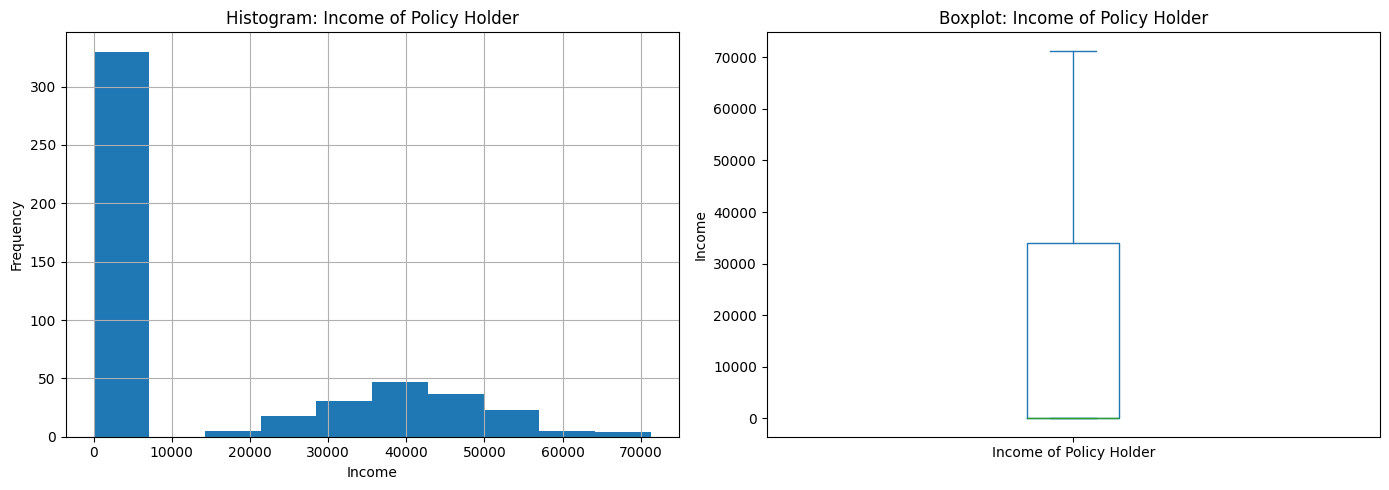

In [77]:
# QUESTION: What is the distribution of the 'Income of Policy Holder' feature? Histogram and boxplot views.
# Plot histogram and boxplot for Income feature to identify patterns and outliers

# Create subplots for histogram and boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
df['Income of Policy Holder'].hist(ax=axes[0])
axes[0].set_title('Histogram: Income of Policy Holder')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')

# Boxplot
df['Income of Policy Holder'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot: Income of Policy Holder')
axes[1].set_ylabel('Income')

plt.tight_layout()
plt.show()

### Visualizing Categorical Features

**Bar plots** show the frequency distribution of categorical variables. Look for:
- Imbalanced categories (one category dominates)
- Rare categories (categories with very few examples)
- Missing values (shown if `dropna=False`)

These insights help us decide whether to combine categories, remove rare ones, or impute missing values.

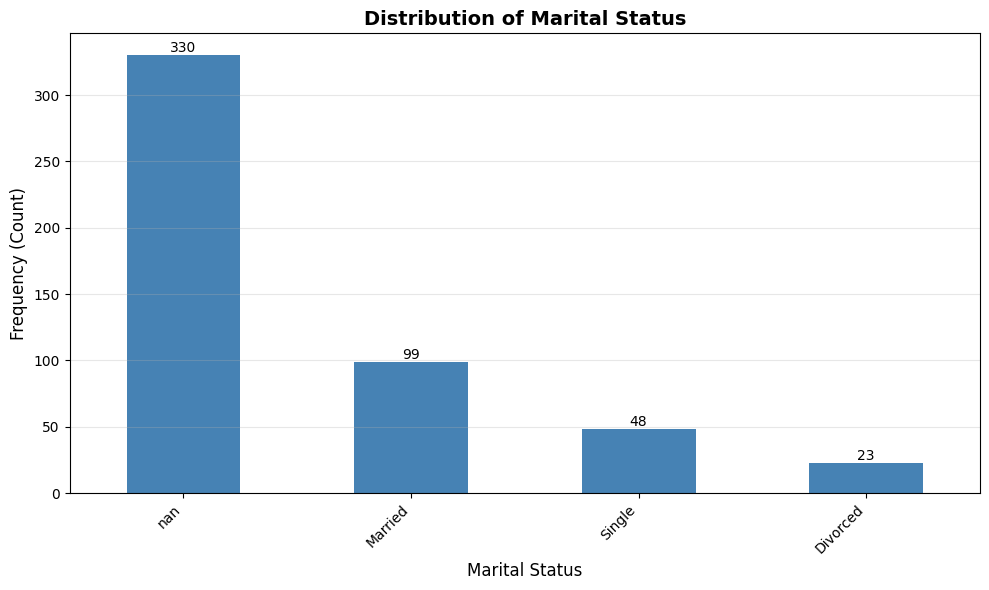

In [78]:
# QUESTION: How are the categories distributed in 'Marital Status'? Are any categories rare or heavily dominant?
# Plot a barplot for categorical feature 'Marital Status'
plt.figure(figsize=(10, 6))
ax = df['Marital Status'].value_counts(dropna=False).plot(kind='bar', color='steelblue')
plt.title('Distribution of Marital Status', fontsize=14, fontweight='bold')
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

<Figure size 2000x2000 with 0 Axes>

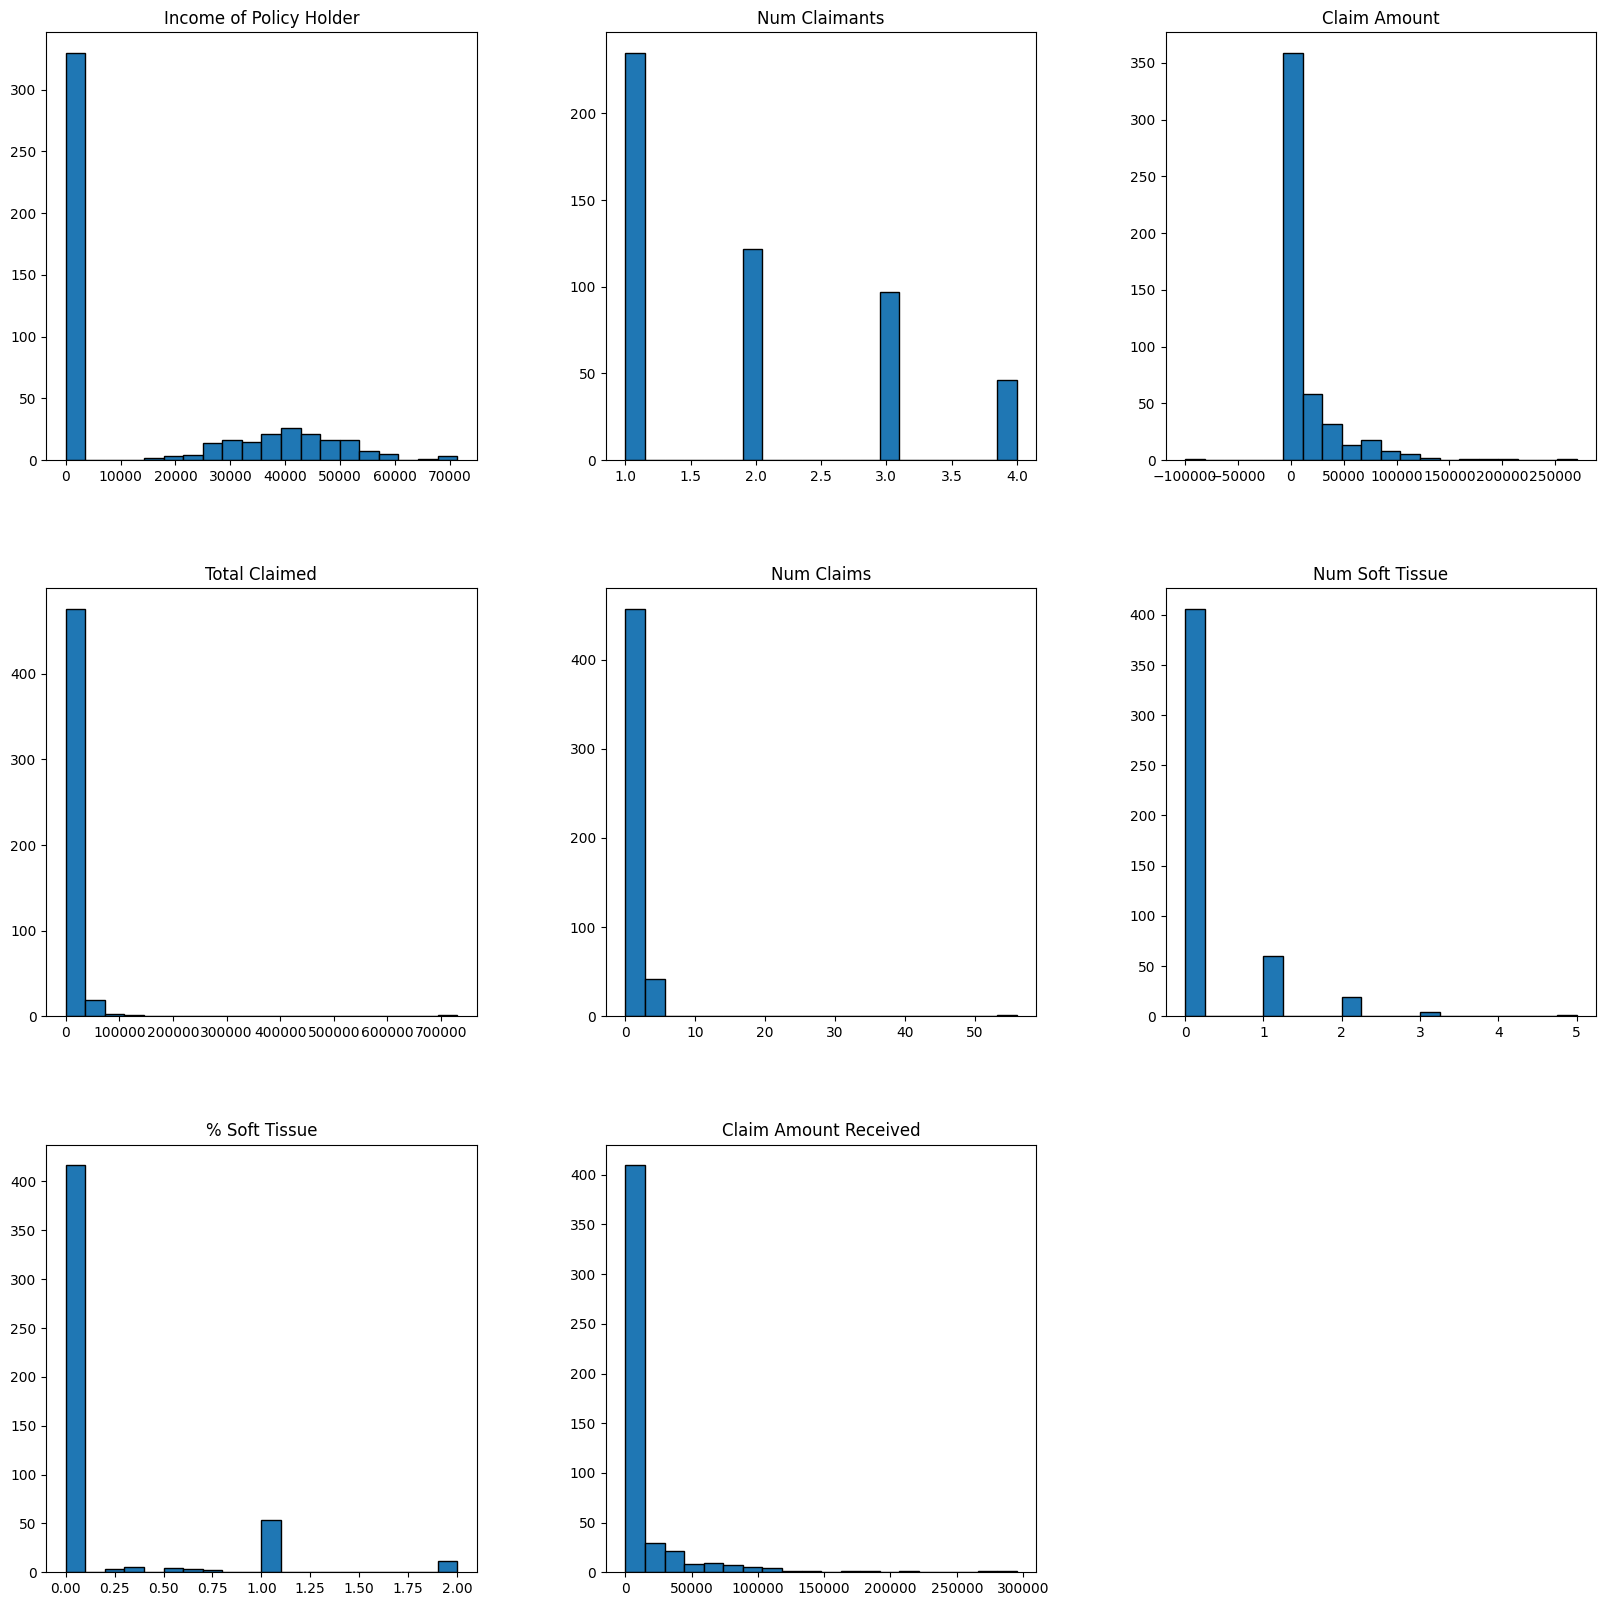

✓ Histograms saved to 'MotorInsurance-DataQualityReport-NumericFeatures-Histograms.png'


In [79]:
# QUESTION: Can we visualize the distributions of all numeric features at once to get a comprehensive view of data quality?
#http://pandas.pydata.org/pandas-docs/stable/visualization.html
# We can plot the histogram of all numeric features at the same time.
fig = plt.figure(figsize=(20, 20))
df[numeric_columns].hist(bins=20, figsize=(20, 20), edgecolor='black', grid=False)

# Add a main title
fig.suptitle('Histograms of All Numeric Features', fontsize=20, fontweight='bold', y=0.995)

# We can save the plot into a file as shown below.
plt.savefig('MotorInsurance-DataQualityReport-NumericFeatures-Histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Histograms saved to 'MotorInsurance-DataQualityReport-NumericFeatures-Histograms.png'")

### Step6: Comprehensive Summary

Let's create a single summary view with key findings for both numeric and categorical features.

In [84]:
# Create a comprehensive summary for each group: numeric and categorical features
print("="*80)
print("DATA QUALITY SUMMARY")
print("="*80)
print(f"\nTotal Features: {len(numeric_columns) + len(category_columns)}")
print(f"  - Numeric Features: {len(numeric_columns)}")
print(f"  - Categorical Features: {len(category_columns)}")
print(f"\n✓ Numeric summary saved to 'MotorInsurance-DataQualityReport-NumericFeatures-Summary-Table.csv'")
print(f"✓ Categorical summary saved to 'MotorInsurance-DataQualityReport-CategoricalFeatures-Summary-Table.csv'")

display(df_numeric_dqr)
display(df_categorical_dqr)

DATA QUALITY SUMMARY

Total Features: 14
  - Numeric Features: 8
  - Categorical Features: 6

✓ Numeric summary saved to 'MotorInsurance-DataQualityReport-NumericFeatures-Summary-Table.csv'
✓ Categorical summary saved to 'MotorInsurance-DataQualityReport-CategoricalFeatures-Summary-Table.csv'


,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
Income of Policy Holder,500.0,13739.99,20081.54,0.0,0.00,0.0,33918.50,71284.0,0.0,171
Num Claimants,500.0,1.91,1.01,1.0,1.00,2.0,3.00,4.0,0.0,4
Claim Amount,500.0,16373.20,29426.28,-99999.0,3322.25,5663.0,12245.50,270200.0,0.0,493
Total Claimed,500.0,9597.19,35655.69,0.0,0.00,0.0,11282.75,729792.0,0.0,235
Num Claims,500.0,0.80,2.67,0.0,0.00,0.0,1.00,56.0,0.0,7
Num Soft Tissue,490.0,0.23,0.59,0.0,0.00,0.0,0.00,5.0,2.0,5
% Soft Tissue,500.0,0.17,0.43,0.0,0.00,0.0,0.00,2.0,0.0,9
Claim Amount Received,500.0,13051.94,30547.19,0.0,0.00,3253.5,8191.75,295303.0,0.0,329


,count,unique,top,freq,%missing,cardinality
ID,500,500,1,1,0.0,500
Insurance Type,500,1,CI,500,0.0,1
Marital Status,170,3,Married,99,66.0,3
Injury Type,500,4,Broken Limb,177,0.0,4
Overnight Hospital Stay,500,2,No,354,0.0,2
Fraud Flag,500,2,0,332,0.0,2


## Data Understanding: Data Quality Plan
After having investigated every feature in the dataset, and noting down and discussing issues with each feature, we move to the Data Quality Plan. The plan lists each feature and the problem identified, as well as the solution that will be implemented for the feature, in order to address the problem identified.

For example, a potential plan start:

    
| Feature                 | Feature Type               |Data Quality Issue         | Handling Strategy         |
|-------------------------|----------------------------|---------------------------|----------------------------
|Marital Status           | category                   | Missing Values (60%)      | Too many missing values. Investigate if missing values can be inferred from other columns. If not, drop feature.              |
|Insurance Type           | category                   | Cardinality=1              | Constant feature. Drop feature              |
|Income of Policy Holder  | int64                      | More than 50% values are 0 | Investigate cause and decide what to do with this feature|
|Claim Amount             | int64                      | Negative feature value (-99,999.0) | Investigate cause of error and how many rows are affected|



## Exercises

1. **Data Understanding: Data Quality Report.** Design a data quality report for the Motor Insurance dataset (short 2-3 page report). Please describe your thinking around the issues identified for each feature and the solutions proposed. At the lab you can discuss your report and receive feedback on each feature.

**To be continued in Lab4:**

2. **Data Understanding: Data Quality Plan.** Design a data quality plan for the Motor Insurance data.  At the lab you can discuss your plan and receive feedback on each feature.
3. **Implementing Data Quality Strategies.** Update your csv file to include the actions noted in your data quality plan (e.g., drop features, drop rows, handle outliers, fill missing data).
4. **Clean Data.** Save the new data frame to a file with a name that reflects that the data has been cleaned (e.g., motor_isurance_clean_round1.csv).
5. **Data Understanding: Relationships between feature pairs.** Explore relationships between feature pairs by using appropriate plots, as discussed in the lecture and texbook.

Note: We will discuss the Data Quality Report and Data Quality Plan for this dataset in Lab3 and Lab4.
